In [17]:
import pandas as pd

In [2]:
tmp_str = """calendar_date, date_key, is_trading_day, weekday, is_weekend, source, calendar_name, calendar_timezone, effective_after, updated_at, year"""

In [3]:
for i in tmp_str.split(", "): print(i)

calendar_date
date_key
is_trading_day
weekday
is_weekend
source
calendar_name
calendar_timezone
effective_after
updated_at
year


In [ ]:
Parquet 文件
│
├── 文件头
│   └── Magic Number: PAR1
│
├── 数据区
│   │
│   ├── Row Group 0
│   │   │
│   │   ├── Column Chunk: calendar_date
│   │   │   ├── Page Header
│   │   │   ├── Data Page
│   │   │   ├── Data Page
│   │   │   └── ...
│   │   │
│   │   ├── Column Chunk: is_trading_day
│   │   │   ├── Page Header
│   │   │   ├── Data Page
│   │   │   └── ...
│   │   │
│   │   └── ...
│   │
│   ├── Row Group 1
│   │   └── ...
│   │
│   └── Row Group N
│       └── ...
│
└── Footer
    │
    ├── FileMetaData
    │   │
    │   ├── version
    │   │
    │   ├── schema
    │   │   ├── calendar_date : DATE
    │   │   ├── is_trading_day : BOOLEAN
    │   │   └── ...
    │   │
    │   ├── num_rows
    │   │
    │   ├── row_groups
    │   │   │
    │   │   ├── RowGroupMetaData 0
    │   │   │   ├── num_rows
    │   │   │   ├── total_byte_size
    │   │   │   │
    │   │   │   └── columns
    │   │   │       ├── ColumnChunkMetaData: calendar_date
    │   │   │       │   ├── physical_type
    │   │   │       │   ├── compression
    │   │   │       │   ├── encodings
    │   │   │       │   ├── data_page_offset
    │   │   │       │   ├── dictionary_page_offset
    │   │   │       │   ├── total_compressed_size
    │   │   │       │   ├── total_uncompressed_size
    │   │   │       │   └── statistics
    │   │   │       │       ├── min
    │   │   │       │       ├── max
    │   │   │       │       ├── null_count
    │   │   │       │       └── ...
    │   │   │       │
    │   │   │       └── ColumnChunkMetaData: ...
    │   │   │
    │   │   └── RowGroupMetaData N
    │   │
    │   ├── key_value_metadata
    │   │   ├── pandas metadata
    │   │   ├── Arrow metadata
    │   │   └── 用户自定义 metadata
    │   │
    │   └── created_by
    │
    ├── FileMetaData 长度
    │
    └── Magic Number: PAR1

In [ ]:
bash -lc python - <<'PY'
from PIL import Image
from pathlib import Path
p=Path('/mnt/data/mg_extract/images')
rows=[]
for f in p.glob('*'):
    try:
        im=Image.open(f)
        rows.append((f.name, im.size[0], im.size[1], f.stat().st_size))
    except: pass
for r in sorted(rows, key=lambda x:x[1]*x[2], reverse=True)[:80]:
    print(r)
PY

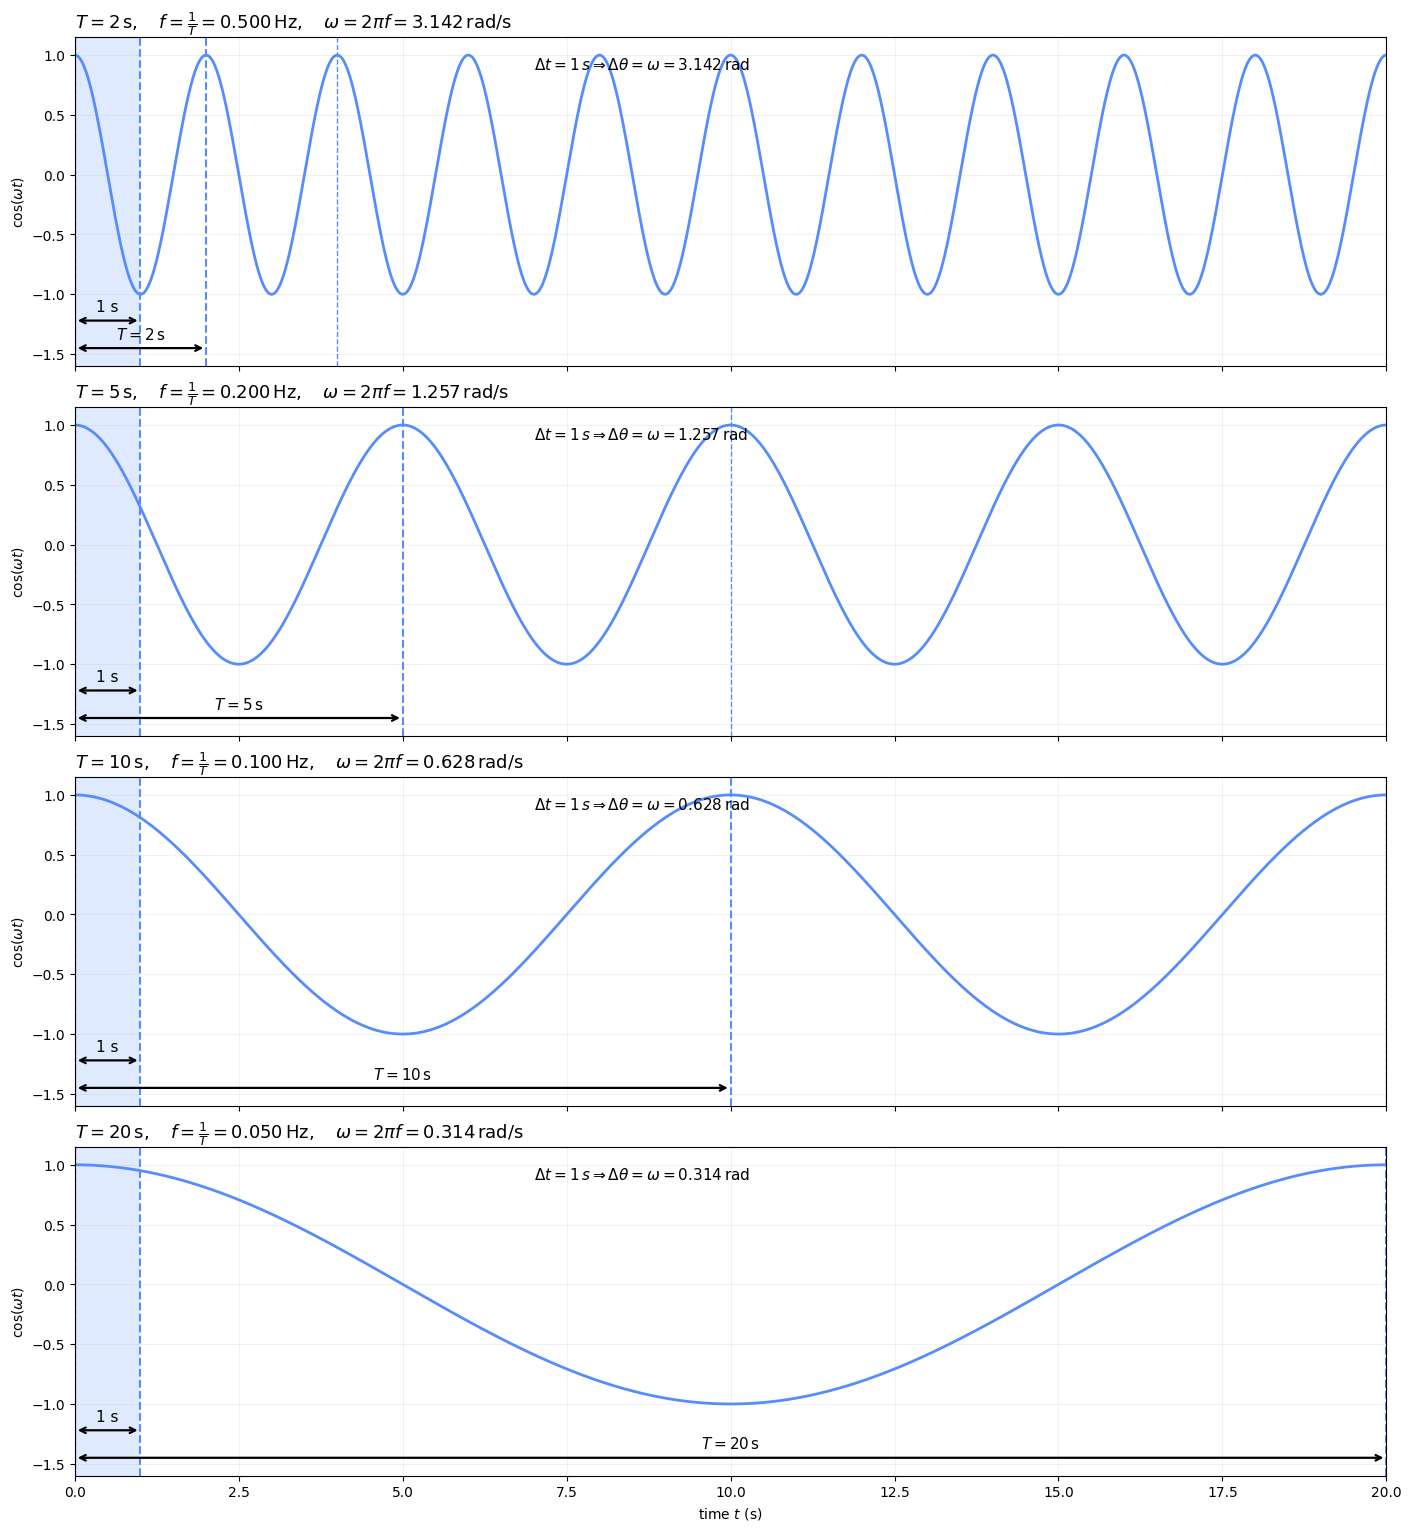

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cos_fixed_1s(T_list, x_max=20, points_per_second=400):
    """
    所有子图使用相同的横轴范围 [0, x_max]，
    因此“1秒”在每张图中的视觉长度固定。
    """
    n = len(T_list)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.8 * n), sharex=True, layout="constrained")

    if n == 1:
        axes = [axes]

    t = np.linspace(0, x_max, int(x_max * points_per_second) + 1)

    for ax, T in zip(axes, T_list):
        f = 1 / T
        omega = 2 * np.pi * f
        x = np.cos(omega * t)

        ax.plot(t, x, linewidth=2)

        # 高亮前 1 秒
        ax.axvspan(0, 1, alpha=0.18)

        # 关键线
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.axvline(1, linestyle="--", linewidth=1.5)
        ax.axvline(T, linestyle="--", linewidth=1.5, label="T")

        # 如果 2T 在显示范围内，也画出来
        if 2 * T <= x_max:
            ax.axvline(2 * T, linestyle="--", linewidth=1)

        # 画 1 秒长度
        y1 = -1.22
        ax.annotate(
            "",
            xy=(1, y1),
            xytext=(0, y1),
            arrowprops=dict(arrowstyle="<->", linewidth=1.6)
        )
        ax.text(0.5, y1 + 0.05, "1 s", ha="center", va="bottom", fontsize=11)

        # 画一个周期长度
        y2 = -1.45
        ax.annotate(
            "",
            xy=(T, y2),
            xytext=(0, y2),
            arrowprops=dict(arrowstyle="<->", linewidth=1.6)
        )
        ax.text(T / 2, y2 + 0.05, rf"$T={T}\,$s", ha="center", va="bottom", fontsize=11)

        # 第一秒对应的相位推进
        ax.text(
            x_max * 0.35,
            0.92,
            rf"$\Delta t=1\,s \Rightarrow \Delta\theta=\omega={omega:.3f}\,\mathrm{{rad}}$",
            fontsize=11,
            va="center"
        )

        ax.set_xlim(0, x_max)
        ax.set_ylim(-1.6, 1.15)
        ax.set_ylabel(r"$\cos(\omega t)$")
        ax.set_title(
            rf"$T={T}\,\mathrm{{s}},\quad f=\frac{{1}}{{T}}={f:.3f}\,\mathrm{{Hz}},\quad "
            rf"\omega=2\pi f={omega:.3f}\,\mathrm{{rad/s}}$",
            loc="left",
            fontsize=13
        )
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("time $t$ (s)")
    plt.show()


# 示例
T_list = [2, 5, 10, 20]
plot_cos_fixed_1s(T_list, x_max=20)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_with_omega_slider(omega=1.0, x_max=20):
    """
    固定横轴范围 [0, x_max]，因此 1 秒在图中的长度固定。
    滑动 omega，自动更新 f 和 T。

    额外标出：
    1. omega = 1 时，基准周期 T0 = 2π 的第一个周期右边界
    2. 在 [0, 2π] 上叠加单位角频率的参考曲线 y = cos(t)，半透明显示
    """
    f = omega / (2 * np.pi)
    T = 2 * np.pi / omega

    # 单位角频率下的基准周期
    T0 = 2 * np.pi

    t = np.linspace(0, x_max, 4000)
    x = np.cos(omega * t)

    fig, ax = plt.subplots(figsize=(14, 6.2), layout="constrained")

    # 当前 omega 对应的主曲线
    ax.plot(t, x, linewidth=2, label=rf"$\cos({omega:.3f}t)$")

    # -------------------------
    # 新增：单位角频率 omega=1 的第一个周期曲线，半透明叠加
    # -------------------------
    t_ref = np.linspace(0, min(T0, x_max), 1200)
    x_ref = np.cos(t_ref)
    ax.plot(
        t_ref,
        x_ref,
        linewidth=3,
        alpha=0.35,
        label=r"reference: $\cos(t)$ on $[0,2\pi]$"
    )

    # 高亮前 1 秒：视觉长度固定
    ax.axvspan(0, 1, alpha=0.18)

    # 关键竖线
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axvline(1, linestyle="--", linewidth=1.5)

    # 当前 omega 对应的周期 T 的位置
    if T <= x_max:
        ax.axvline(T, linestyle="--", linewidth=1.5)
    if 2 * T <= x_max:
        ax.axvline(2 * T, linestyle="--", linewidth=1)

    # 单位角频率下的基准周期边界
    if T0 <= x_max:
        ax.axvline(T0, linestyle=":", linewidth=2)

    # 画 1 秒长度
    y1 = -1.22
    ax.annotate(
        "",
        xy=(1, y1),
        xytext=(0, y1),
        arrowprops=dict(arrowstyle="<->", linewidth=1.6)
    )
    ax.text(0.5, y1 + 0.05, "1 s", ha="center", va="bottom", fontsize=11)

    # 画当前 omega 下的一个周期长度
    y2 = -1.45
    if T <= x_max:
        ax.annotate(
            "",
            xy=(T, y2),
            xytext=(0, y2),
            arrowprops=dict(arrowstyle="<->", linewidth=1.6)
        )
        ax.text(
            T / 2,
            y2 + 0.05,
            rf"$T={T:.3f}\,$s",
            ha="center",
            va="bottom",
            fontsize=11
        )
    else:
        ax.text(
            x_max * 0.55,
            y2 + 0.05,
            rf"$T={T:.3f}\,$s（超出当前显示范围）",
            ha="left",
            va="bottom",
            fontsize=11
        )

    # 画单位角频率下的基准周期长度 [0, 2π]
    y3 = -1.68
    if T0 <= x_max:
        ax.annotate(
            "",
            xy=(T0, y3),
            xytext=(0, y3),
            arrowprops=dict(arrowstyle="<->", linewidth=1.6)
        )
        ax.text(
            T0 / 2,
            y3 + 0.05,
            r"$\omega=1 \Rightarrow T_0=2\pi\ \mathrm{s}$",
            ha="center",
            va="bottom",
            fontsize=11
        )

        ax.text(
            T0 + 0.12,
            0.15,
            r"$t=2\pi$" "\n" r"(unit-$\omega$ first-period boundary)",
            fontsize=10,
            va="center"
        )

    # 文字说明
    ax.text(
        x_max * 0.30,
        0.92,
        rf"$\omega={omega:.3f}\,\mathrm{{rad/s}}$"
        "\n"
        rf"$f=\omega/(2\pi)={f:.3f}\,\mathrm{{Hz}}$"
        "\n"
        rf"$T=2\pi/\omega={T:.3f}\,\mathrm{{s}}$"
        "\n"
        rf"$1\,\mathrm{{s}} \Rightarrow \Delta\theta=\omega\cdot 1={omega:.3f}\,\mathrm{{rad}}$",
        fontsize=11,
        va="top"
    )

    ax.set_xlim(0, x_max)
    ax.set_ylim(-1.85, 1.15)
    ax.set_xlabel("time $t$ (s)")
    ax.set_ylabel(r"$\cos(\omega t)$")
    ax.set_title(
        r"Fixed x-axis: 1 second has constant visual length; only $\omega$ changes",
        loc="left",
        fontsize=13
    )
    ax.grid(alpha=0.25)
    ax.legend()

    plt.show()


interact(
    plot_with_omega_slider,
    omega=FloatSlider(
        value=1.0,
        min=0.2,
        max=8.0,
        step=0.01,
        description=r'$\omega$'
    )
);

interactive(children=(FloatSlider(value=1.0, description='$\\omega$', max=8.0, min=0.2, step=0.01), IntSlider(…